In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# Paths to processed data
base_dir = "/Users/adrian/Athena/data/Cleaned Data"
images_path = os.path.join(base_dir, "cleaned_floorplan_images.csv")
human_annotations_path = os.path.join(base_dir, "cleaned_human_annotations.csv")
artificial_annotations_path = os.path.join(base_dir, "cleaned_artificial_annotations.csv")

# Load data
images_df = pd.read_csv(images_path)
human_annotations_df = pd.read_csv(human_annotations_path)
artificial_annotations_df = pd.read_csv(artificial_annotations_path)

# Path to floorplan images
image_folder = "/Users/adrian/Documents/Tell2Design Data/General Data/floorplan_image"


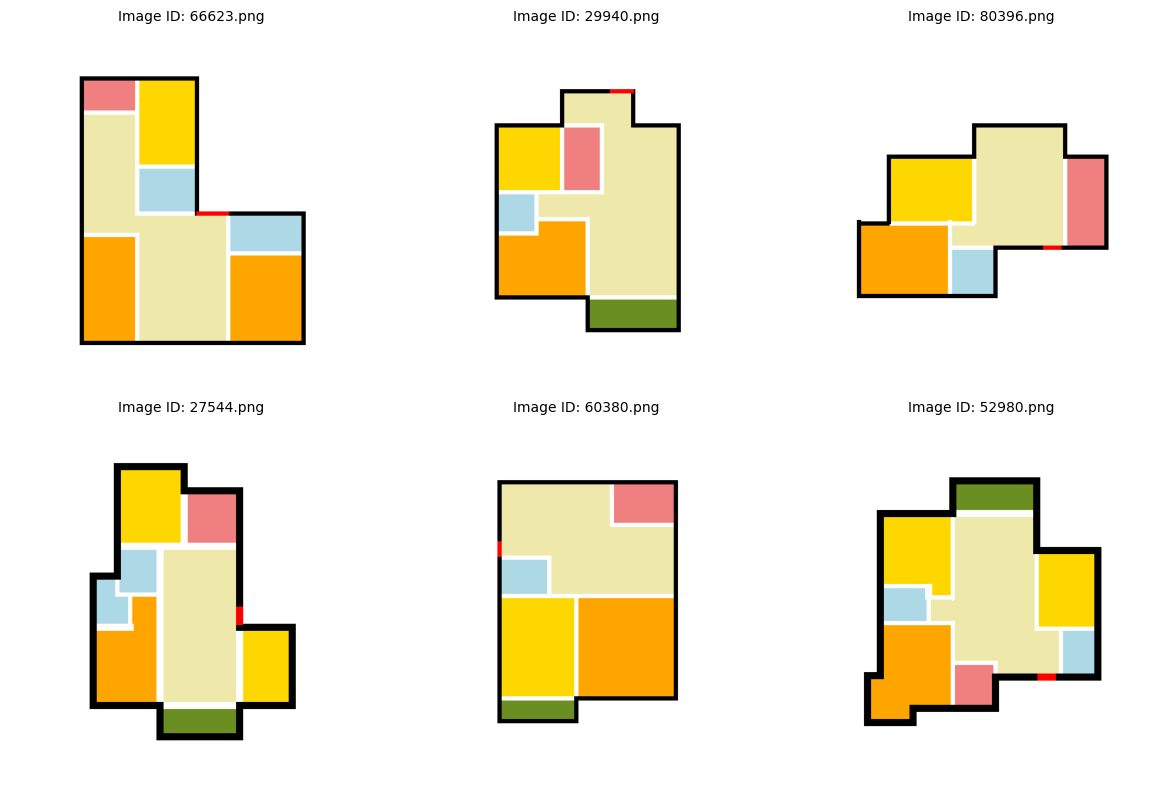

In [3]:
# Visualize a 2x3 grid of sample images
sample_images = images_df.sample(6)  # Adjust the number for a 2x3 grid

fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # Create a 2x3 grid of subplots
axes = axes.flatten()  # Flatten the axes for easier iteration

for i, (_, row) in enumerate(sample_images.iterrows()):
    img_path = os.path.join(image_folder, os.path.basename(row["image_path"]))
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Image ID: {os.path.basename(row['image_path'])}", fontsize=10)
        axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, "Image not found", horizontalalignment="center", verticalalignment="center")
        axes[i].axis("off")

# Hide any remaining empty axes
for j in range(len(sample_images), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()



In [5]:
# Display a random sample of human annotations
sample_human = human_annotations_df.sample(3)

for _, row in sample_human.iterrows():
    print(f"Image ID: {row['image_id']}")
    print(f"Annotation: {row['annotation']}")
    print("-" * 50)


Image ID: 48430.png
Annotation: balcony takes south east corner master room north approximately 16 feet 6 feet bathroom approximate size 14 feet 6 feet adjoined north west living room master room south common room 1 occupies south west corner 14 feet 12 feet living room common room 2 north master room east common room 2 western living room north east common room 1 south 14 feet 12 feet kitchen north east corner adjoined south east living room approximately 12 feet 16 feet living room situated north west corner approximately 29 feet 34 feet kitchen east bathroom master room common room 1 2 south master room east bathroom balcony common room 1 living room west size approximately 16 feet 16 feet
--------------------------------------------------
Image ID: 50920.png
Annotation: balcony southern edge house south living room approximate dimensions 11x4 bathroom western edge house common room north master south living room east approximate dimensions 7x8 common room northwest corner house liv

In [6]:
# Display a random sample of artificial annotations
sample_artificial = artificial_annotations_df.sample(3)

for _, row in sample_artificial.iterrows():
    print(f"Image ID: {row['image_id']}")
    print(f"Annotation: {row['description']}")
    print("-" * 50)


Image ID: 77309.png
Annotation: good common room 1 north west corner 200 sqft aspect ratio 5 7 bathroom south west corner 50 sqft aspect ratio 3 2 like living room 550 sqft aspect ratio 1 1 like master room north east corner approx 300 sqft aspect ratio 1 1 make balcony north 50 sqft aspect ratio 6 1 like kitchen south 100 sqft aspect ratio 3 4 common room 2 south approx 150 sqft aspect ratio 13 11
--------------------------------------------------
Image ID: 79594.png
Annotation: make bathroom north approx 50 sqft aspect ratio 8 13 make common room north 200 sqft aspect ratio 11 5 make balcony 1 south 50 sqft aspect ratio 7 1 make master room south 350 sqft aspect ratio 8 7 living room 550 sqft aspect ratio 1 2 like kitchen north 50 sqft aspect ratio 4 1 balcony 2 south 100 sqft aspect ratio 7 2
--------------------------------------------------
Image ID: 56040.png
Annotation: common room 1 south 50 sqft aspect ratio 13 10 kitchen south 100 sqft aspect ratio 11 13 like living room appr

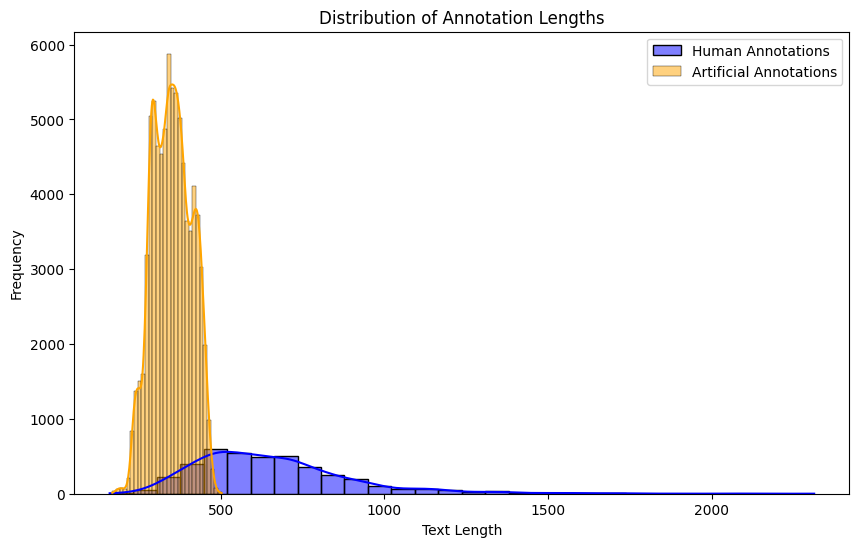

In [7]:
# Calculate text lengths
human_annotations_df["text_length"] = human_annotations_df["annotation"].apply(len)
artificial_annotations_df["text_length"] = artificial_annotations_df["description"].apply(len)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(human_annotations_df["text_length"], bins=30, color="blue", label="Human Annotations", kde=True)
sns.histplot(artificial_annotations_df["text_length"], bins=30, color="orange", label="Artificial Annotations", kde=True)
plt.title("Distribution of Annotation Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()


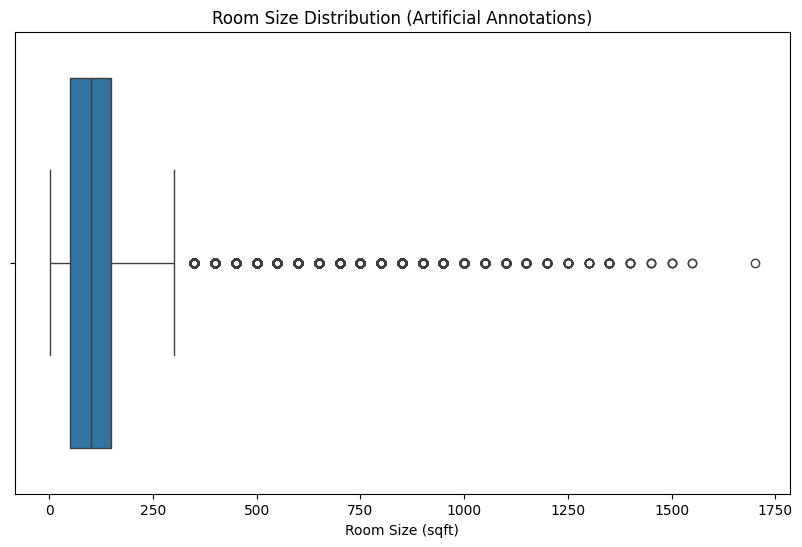

Potential Outliers:
        image_id                                        description  \
6      42748.png  living room 650 sqft aspect ratio 7 15 make ma...   
20     52324.png  make living room approx 700 sqft aspect ratio ...   
30     41259.png  make living room 550 sqft aspect ratio 5 9 bal...   
31     68679.png  great living room approx 550 sqft aspect ratio...   
43     35448.png  like living room 700 sqft aspect ratio 6 7 mak...   
...          ...                                                ...   
80744  79927.png  like living room 1350 sqft aspect ratio 2 3 ma...   
80757  41594.png  living room approx 1150 sqft aspect ratio 1 1 ...   
80782  40713.png  make living room 600 sqft aspect ratio 13 10 m...   
80785  37227.png  great living room 900 sqft aspect ratio 14 13 ...   
80786  28984.png  good living room 700 sqft aspect ratio 7 6 kit...   

       text_length  room_sizes  
6              298       650.0  
20             239       700.0  
30             382       550

In [8]:
# Extract room sizes if available in artificial annotations
artificial_annotations_df["room_sizes"] = artificial_annotations_df["description"].str.extract(r'(\d+) sqft').astype(float)

# Plot room size distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x=artificial_annotations_df["room_sizes"])
plt.title("Room Size Distribution (Artificial Annotations)")
plt.xlabel("Room Size (sqft)")
plt.show()

# Highlight outliers
outliers = artificial_annotations_df[artificial_annotations_df["room_sizes"] > artificial_annotations_df["room_sizes"].quantile(0.95)]
print("Potential Outliers:")
print(outliers)
